# Last-layer Low-Rank Kalman filter (LL-LRKF)
Kalman-filter-based low-rank Bayesian last-layer method.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import jax
import keras
import optax
import numpy as np
import pandas as pd
import flax.linen as nn
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from tqdm import tqdm
from functools import partial
from jax.flatten_util import ravel_pytree

from rebayes_mini.methods import low_rank_filter_revised as lrkf
from rebayes_mini.methods import low_rank_last_layer as flores

In [4]:
sns.set_palette("colorblind")

In [5]:
%config InlineBackend.figure_format = "retina"

## Load dataset

tcmalloc: large alloc 1228800000 bytes == 0x55ee7b40a000 @  0x7f92e5e3a680 0x7f92e5e5b824 0x7f92d2641595 0x7f92d2641a03 0x7f92d26607f9 0x7f92d2660e40 0x7f92d26b6fce 0x7f92d26b897a 0x7f92d273588d 0x7f92d273e538 0x55ed62acd166 0x55ed62b779b5 0x7f92d26bf84b 0x55ed62b44401 0x55ed629b1526 0x55ed62b75cae 0x55ed62b9043d 0x55ed629b233e 0x55ed62b8b002 0x55ed62b8c267 0x55ed629b2bcd 0x55ed62aff03c 0x55ed62afebad 0x55ed62ae0513 0x55ed629ad688 0x55ed62b8b002 0x7f92e45711e6 0x7f92e457199a 0x55ed62acbdea 0x55ed62c057dc 0x55ed62a69916


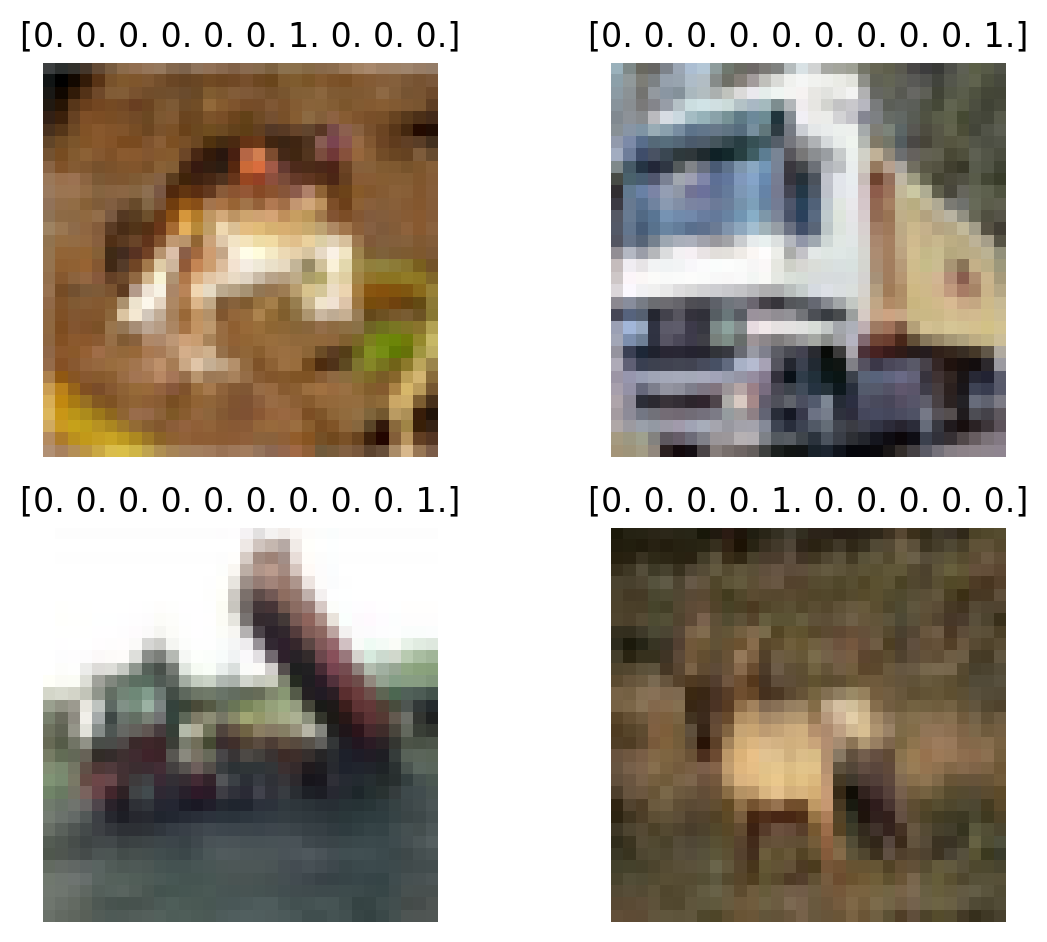

In [6]:
# (X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
# X_train = einops.rearrange(X_train, "s w h -> s (w h)") / 255
# X_test = einops.rearrange(X_test, "s w h -> s (w h)") / 255
y_train = jax.nn.one_hot(y_train, 10).squeeze()
X_train = jnp.array(X_train / 255)
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.ravel()):
    ax.imshow(X_train[i], cmap="bone")
    ax.set_title(y_train[i])
    ax.axis("off")
plt.tight_layout()

In [7]:
X_train.shape

(50000, 32, 32, 3)

## Train

In [8]:
X_eval = X_test[:5_000]
y_eval = y_test[:5_000]

In [9]:
import flax.linen as nn

class VGG(nn.Module):
    num_classes: int = 10

    @nn.compact
    def __call__(self, x):
        x = x if len(x.shape) > 3 else x[None, :]
        
        # First block
        x = nn.Conv(features=64, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.Conv(features=64, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
        
        # Second block
        x = nn.Conv(features=128, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.Conv(features=128, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
        
        # Third block
        x = nn.Conv(features=256, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
        
        # Flatten and Dense layers
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(features=256)(x)
        x = nn.elu(x)
        x = nn.Dense(features=256)(x)
        x = nn.elu(x)
        x = nn.Dense(features=self.num_classes, name="last_layer")(x)
        
        return x.squeeze()

keytest = jax.random.PRNGKey(3)
model = VGG()
pt = model.init(keytest, X_train[:2])
len(ravel_pytree(pt)[0])

1672522

In [10]:
class VGGPlusBlock(nn.Module):
    """VGG‑style net with an extra 4th block (512→512 channels)."""
    num_classes: int = 10

    @nn.compact
    def __call__(self, x):
        x = x if len(x.shape) > 3 else x[None, :]

        # Block 1: 64→64
        x = nn.Conv(features=64,  kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.Conv(features=64,  kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2,2), strides=(2,2))

        # Block 2: 128→128
        x = nn.Conv(features=128, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.Conv(features=128, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2,2), strides=(2,2))

        # Block 3: 256
        x = nn.Conv(features=256, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2,2), strides=(2,2))

        # **New Block 4: 512→512**
        x = nn.Conv(features=512, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.Conv(features=512, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2,2), strides=(2,2))

        # Flatten + Dense head
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(features=256)(x)
        x = nn.elu(x)
        x = nn.Dense(features=256)(x)
        x = nn.elu(x)
        x = nn.Dense(features=self.num_classes, name="last_layer")(x)
        return x.squeeze()


keytest = jax.random.PRNGKey(3)
model = VGGPlusBlock()
pt = model.init(keytest, X_train[:2])
len(ravel_pytree(pt)[0])

4688202

In [11]:
class VGGMinusBlock(nn.Module):
    """VGG‑style net with the 3rd block removed."""
    num_classes: int = 10

    @nn.compact
    def __call__(self, x):
        x = x if len(x.shape) > 3 else x[None, :]

        # Block 1: 64→64
        x = nn.Conv(features=64,  kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.Conv(features=64,  kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2,2), strides=(2,2))

        # Block 2: 128→128
        x = nn.Conv(features=128, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.Conv(features=128, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.elu(x)
        x = nn.avg_pool(x, window_shape=(2,2), strides=(2,2))

        # (Block 3 removed → go straight to head)

        # Flatten + Dense head
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(features=256)(x)
        x = nn.elu(x)
        x = nn.Dense(features=256)(x)
        x = nn.elu(x)
        x = nn.Dense(features=self.num_classes, name="last_layer")(x)
        return x.squeeze()


keytest = jax.random.PRNGKey(3)
model = VGGMinusBlock()
pt = model.init(keytest, X_train[:2])
len(ravel_pytree(pt)[0])

2425930

## Revised version

In [12]:
def callbackfn(bel_update, bel_pred, y, x, agent):
    """
    Compute test accuracy at every timestep
    """
    yhat = agent.predict_fn(bel_pred, x)
    acc = y.argmax() == yhat.argmax()
    return acc
    # return acc, bel_update.epull, bel_update.econs

In [13]:
def mean_fn(params, x):
    eta = model.apply(params, x)
    return jax.nn.softmax(eta)

def cov_fn(mean, eps=0.1):
    return jnp.diag(mean) - jnp.outer(mean, mean) + jnp.eye(len(mean)) * eps

In [14]:
n_sims = 1
keys = jax.random.PRNGKey(314)
keys = jax.random.split(keys, n_sims)
model = VGG()

configs = [
    {"name": "-VGG-1",
     "model": VGGMinusBlock(),
    "rank": 1},
    {"name": "-VGG-5",
     "model": VGGMinusBlock(),
    "rank": 5},
    {"name": "-VGG-10",
     "model": VGGMinusBlock(),
    "rank": 10},
    {"name": "VGG-1",
     "model": VGG(),
    "rank": 1},
    {"name": "VGG-5",
     "model": VGG(),
    "rank": 5},
    {"name": "VGG-10",
     "model": VGG(),
    "rank": 10},
    {"name": "+VGG-1",
     "model": VGGPlusBlock(),
    "rank": 1},
    {"name": "+VGG-5",
     "model": VGGPlusBlock(),
    "rank": 5},
    {"name": "+VGG-10",
     "model": VGGPlusBlock(),
    "rank": 10}
]

In [17]:
n_obs = len(X_train)

In [19]:
res = {}

key = jax.random.PRNGKey(314)
for config in (pbar := tqdm(configs)):
    name = config["name"]
    rank = config["rank"]
    model = config["model"]
    def mean_fn(params, x):
        eta = model.apply(params, x)
        return jax.nn.softmax(eta)

    def run_lrkf(key, rank):
        # key_init, key_shuffle = jax.random.split(key)
        # ix_choice = jax.random.choice(key_shuffle, n_obs, (10_000,), replace=False)
        
        params = model.init(key, X_train[:1])
        agent = lrkf.LowRankCovarianceFilter(
            mean_fn,
            cov_fn,
            dynamics_covariance=0.01,
            rank=rank,
        )
        bel_init = agent.init_bel(params, cov=1.0, low_rank_diag=True)

        n_params = len(bel_init.mean)
        desc = f"{name}: {n_params:,}"
        pbar.set_description(desc)


        cfn = partial(callbackfn, agent=agent)
        bel, hist_lrkf = agent.scan(
            bel_init,
            y_train.at[:10_000].get(),
            X_train.at[:10_000].get(),
            cfn
        )
        return hist_lrkf
    
    hist_lrkf = run_lrkf(key, rank)
    hist_lrkf = jax.tree.map(np.array, hist_lrkf)
    res[name] = hist_lrkf

+VGG-10: 4,688,202: 100%|██████████████████████████████████████████████████████████████████████████████████| 9/9 [26:44<00:00, 178.28s/it]


In [24]:
res_df = pd.DataFrame(res).astype(float)

In [33]:
res_df.to_pickle("vgg-lrkf-res.pkl")

## Load results

In [11]:
res_df = pd.read_pickle("vgg-lrkf-res.pkl")

In [33]:
res_df.mean()

-VGG-1     0.3403
-VGG-5     0.3423
-VGG-10    0.3423
VGG-1      0.3355
VGG-5      0.3384
VGG-10     0.3379
+VGG-1     0.3129
+VGG-5     0.3141
+VGG-10    0.3148
dtype: float64

## Adamw

In [18]:
from rebayes_mini.methods import replay_sgd

In [19]:
def lossfn(params, counter, X, y, fn):
    yhat = fn(params, X)
    loss = optax.losses.softmax_cross_entropy(yhat, y)
    return (loss * counter).sum() / counter.sum()

In [40]:
model_vgg = VGG()
model_vgg_plus = VGGPlusBlock()

In [71]:
%%time
def run_adamw(key, model):
    key_init, key_shuffle = jax.random.split(key)
    
    # ix_choice = jax.random.choice(key_shuffle, n_obs, (n_obs,), replace=False)
    params = model.init(key_init, X_train[:100])
    
    agent = replay_sgd.FifoSGD(
        model.apply,
        lossfn,
        tx=optax.adamw(learning_rate=1e-4),
        buffer_size=1,
        dim_features=(32, 32, 3),
        dim_output=10
    )
    
    cfn = partial(callbackfn, agent=agent)
    bel_init = agent.init_bel(params)
    bel, hist = agent.scan(
        bel_init,
        y_train.at[:10_000].get(),
        X_train.at[:10_000].get(),
        cfn
    )
    return hist

CPU times: user 50 μs, sys: 3 μs, total: 53 μs
Wall time: 107 μs


## VGG

In [72]:
key = jax.random.PRNGKey(3)
# hist_muon = jax.vmap(run_muon)(keys)
hist = run_adamw(key, model_vgg)
hist = jax.tree.map(np.array, hist)

In [73]:
df_adamw = pd.DataFrame(hist.T)
df_adamw.shape

(10000, 1)

In [74]:
df_adamw.mean()

0    0.3442
dtype: float64

## VGG+

In [75]:
key = jax.random.PRNGKey(3)
# hist_muon = jax.vmap(run_muon)(keys)
hist = run_adamw(key, model_vgg_plus)
hist = jax.tree.map(np.array, hist)

In [76]:
df_adamw = pd.DataFrame(hist.T)
df_adamw.shape

(10000, 1)

In [77]:
df_adamw.mean()

0    0.3097
dtype: float64